<a href="https://colab.research.google.com/github/COMP4702-UQ/Pracs-notebook/blob/main/PracW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LINEAR REGRESSION & LOGISTIC REGRESSION

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Mount google colab to drive to access to the dataset (comment if you don't use Colab + Drive)
#from google.colab import drive
#drive.mount('/content/drive/')

## Q1

### (a)

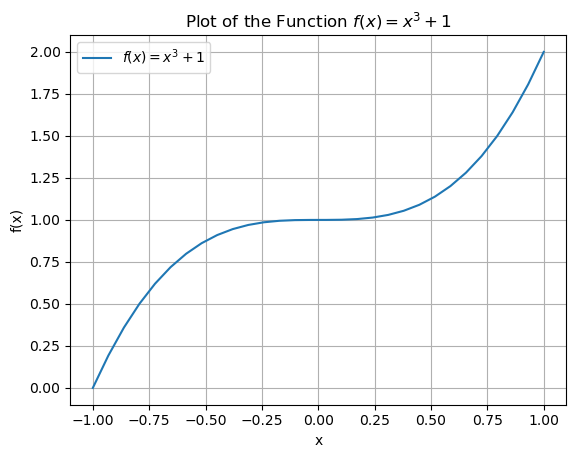

In [4]:
# TODO: Define the function
def f(x):
    return x**3 + 1

# TODO: Generate x values in the specified domain
x_values = np.linspace(-1, 1, 30)

# TODO: Calculate corresponding y values using the function
y_values = [f(x) for x in x_values]

# Plot the function
plt.plot(x_values, y_values, label=r'$f(x) = x^3 + 1$')
plt.title('Plot of the Function $f(x) = x^3 + 1$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

### (b)

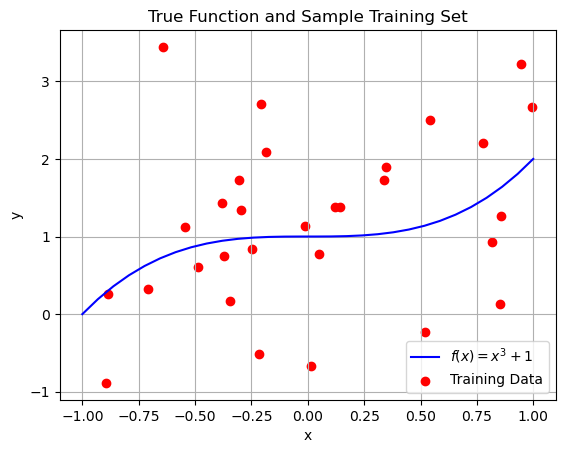

In [5]:
# TODO: Generate 30 random x values in the specified domain
np.random.seed(50)  # for reproducibility
sample_training_x = np.random.uniform(-1, 1, 30)

# TODO: Calculate corresponding y values using the true function and add Gaussian noise
noise = np.random.normal(0, 1, 30)
sample_training_y = f(sample_training_x) + noise

# Plot the true function
plt.plot(x_values, y_values, label=r'$f(x) = x^3 + 1$', color='blue')

# Plot the noisy data points
plt.scatter(sample_training_x, sample_training_y, color='red', label='Training Data')

# Add labels and legend
plt.title('True Function and Sample Training Set')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### (c)

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# TODO: Reshape the data for sklearn (if needed)
X_train = sample_training_x.reshape(-1, 1)

# TODO: Perform linear regression
linear_model = LinearRegression()
linear_model.fit(X_train, sample_training_y)

# TODO: Predict y values using the linear model
sample_training_y_pred = linear_model.predict(X_train)

# TODO: Calculate the sum of squares error
mse = mean_squared_error(sample_training_y, sample_training_y_pred)
print(f'Training Set Sum of Squares Error: {mse}')

Training Set Sum of Squares Error: 1.068860902445247


### (d)

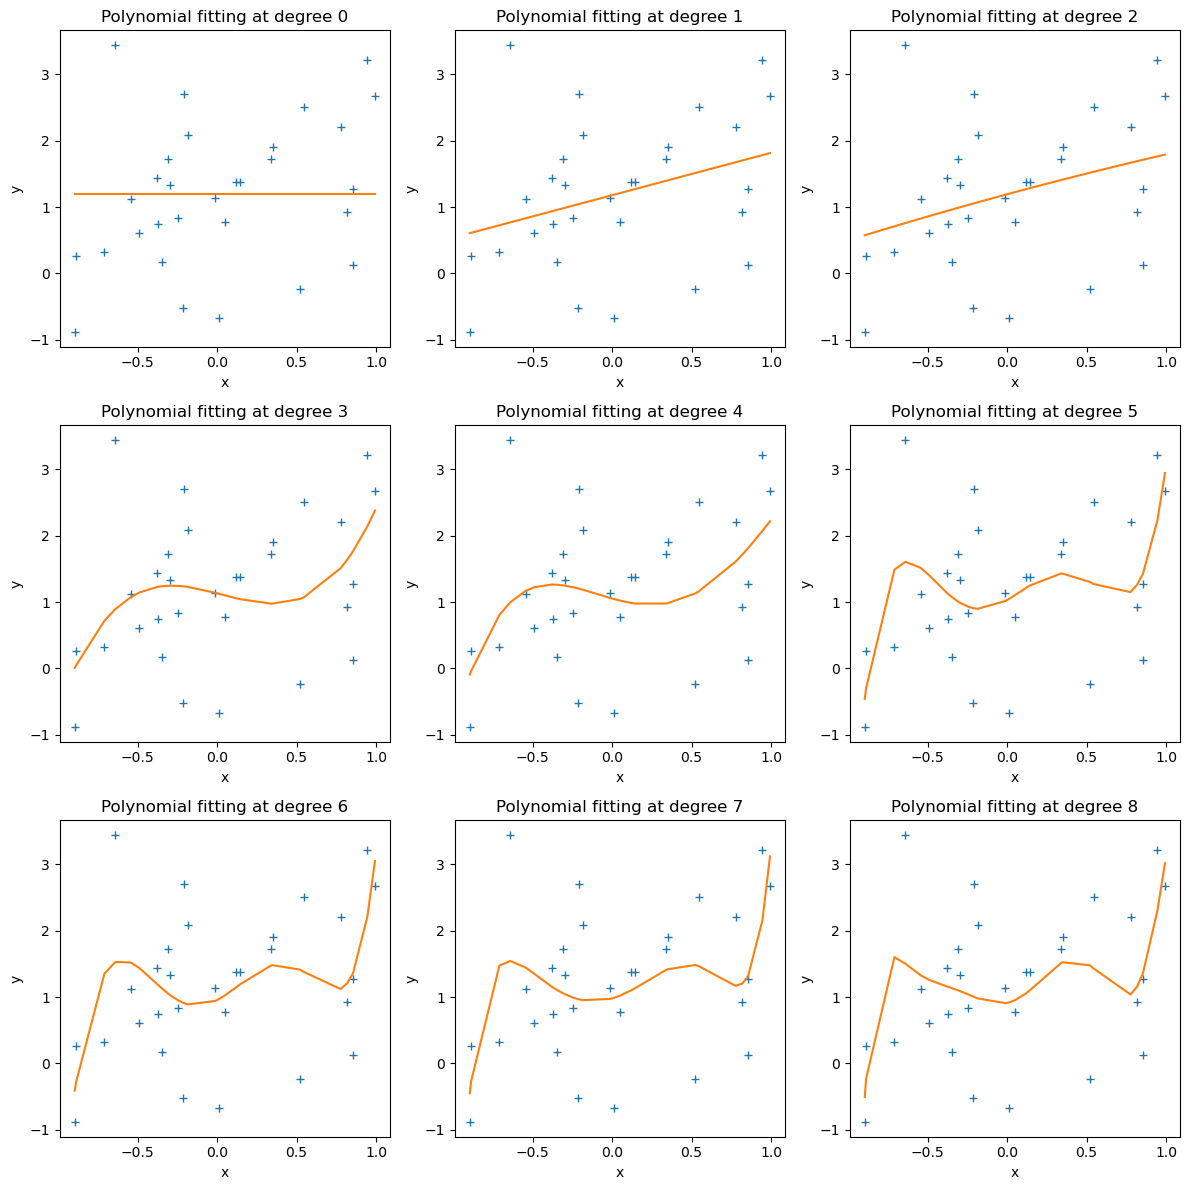

In [7]:
# Perform polynomial regression
from sklearn.preprocessing import PolynomialFeatures

mses = [] # Store MSE for each degree for visualization (optional)

plt.figure(figsize=(12, 12))

# Sort indices once for plotting (x must be sorted for a clean line plot)
sort_idx = np.argsort(sample_training_x)
sample_training_x_sorted = sample_training_x[sort_idx]

# Experiment with different polynomial orders
for degree in range(9):
    plt.subplot(3, 3, degree + 1)

    # TODO: Polynomial regression
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_train)
    poly_model = LinearRegression()
    poly_model.fit(X_poly, sample_training_y)

    # TODO: Predict y values using the polynomial model
    sample_training_y_pred = poly_model.predict(X_poly)
    pred_y_sorted = sample_training_y_pred[sort_idx]

    # TODO: Calculate the sum of squares error
    mse = mean_squared_error(sample_training_y, sample_training_y_pred)
    mses.append(mse)

    # Plot the polynomial function for current degree
    plt.plot(sample_training_x, sample_training_y, '+')
    plt.plot(sample_training_x_sorted, pred_y_sorted)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Polynomial fitting at degree %d' % degree)

plt.tight_layout()
plt.show()

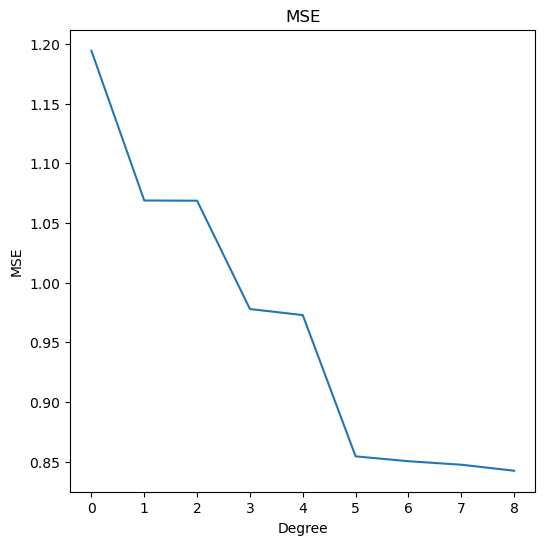

In [9]:
# Plot MSE
plt.figure(figsize=(6,6))
plt.plot(np.arange(0, 9, 1), mses)
plt.title('MSE')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.show()

## Q2

In [1]:
# === Q2 Clean Setup ===
# Re-import all libraries needed for Q2 to avoid state from Q1 bleeding in
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Reset any variables that overlap with Q1
X = y = scaler = linear_model = None

In [2]:
# Load and define dataset
data = pd.read_csv('pokemonregr.csv')

# Handle missing data - drop rows with any missing values
data = data.dropna()

# Define X (features) and y (target: weight_kg = final column)
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Fit linear regression model
linear_model = LinearRegression()
linear_model.fit(X, y)

LinearRegression()

### (c)

In [3]:
# TODO: Coefficients of Linear Model (hint: look at the document of LinearRegression() in sklearn)
pd.DataFrame(zip(data.columns[:-1], linear_model.coef_))

,0,1
0,attack,0.377398
1,defense,0.567722
2,height_m,53.514625
3,sp_attack,0.024600
4,sp_defense,0.153453
5,speed,-0.421540


In [4]:
from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import StandardScaler

# Normalize both features AND target (entire dataframe scaled to [0,1])
scaler_mm = MinMaxScaler()
data_mm = pd.DataFrame(scaler_mm.fit_transform(data), columns=data.columns)

X_mm = data_mm.iloc[:, :-1].values
y_mm = data_mm.iloc[:, -1].values

# Define linear regression model on normalized features
linear_model_mm = LinearRegression()
linear_model_mm.fit(X_mm, y_mm)

print("MinMaxScaler coefficients:")
pd.DataFrame(zip(data.columns[:-1], linear_model_mm.coef_))

MinMaxScaler coefficients:


,0,1
0,attack,0.067945
1,defense,0.127763
2,height_m,0.770765
3,sp_attack,0.004527
4,sp_defense,0.032232
5,speed,-0.073784


In [5]:
from sklearn.preprocessing import StandardScaler

# Normalize both features AND target using StandardScaler (zero mean, unit variance)
scaler_std = StandardScaler()
data_std = pd.DataFrame(scaler_std.fit_transform(data), columns=data.columns)

X_std = data_std.iloc[:, :-1].values
y_std = data_std.iloc[:, -1].values

linear_model_std = LinearRegression()
linear_model_std.fit(X_std, y_std)

print("StandardScaler coefficients:")
pd.DataFrame(zip(data.columns[:-1], linear_model_std.coef_))

StandardScaler coefficients:


,0,1
0,attack,0.111208
1,defense,0.159931
2,height_m,0.528676
3,sp_attack,0.007240
4,sp_defense,0.039304
5,speed,-0.111420


## Q3

### (a)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalize entire dataframe (features + target) to [0,1]
scaler_mm = MinMaxScaler()
data_mm = pd.DataFrame(scaler_mm.fit_transform(data), columns=data.columns)

# Define X, y for normalized features
X_normalized = data_mm.iloc[:, :-1].values
y_normalized = data_mm.iloc[:, -1].values

# Define linear regression model
linear_model_norm = LinearRegression()
linear_model_norm.fit(X_normalized, y_normalized)

# Coefficients of Linear Model
pd.DataFrame(zip(data.columns[:-1], linear_model_norm.coef_))

### (b)

In [ ]:
# TODO: Standardize the test data point using the same scaler

# TODO: Predict the probability of class 1 for the test data point
probability_y1 = ...

print("Probability p(y' = 1 | x'):", probability_y1[0])

Probability p(y' = 1 | x'): 0.3275594820024205


### (c)

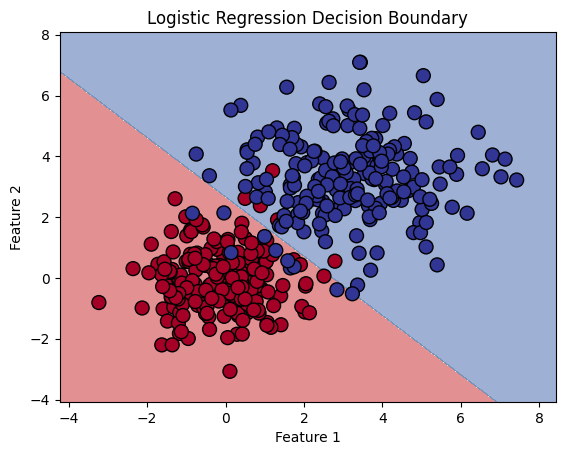

In [ ]:
# Generate a meshgrid of points for plotting the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Standardize the meshgrid points using the same scaler
meshgrid_points = np.c_[xx.ravel(), yy.ravel()]
meshgrid_points_scaled = scaler.transform(meshgrid_points)

# TODO: Predict the class labels for the meshgrid points

# TODO: Reshape the predictions to match the shape of the meshgrid

# Plot the decision boundary and data points
plt.contourf(xx, yy, predictions, cmap='RdYlBu', alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k', marker='o', s=100)

# Plot labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')

# Show the plot
plt.show()